Installing the dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print ("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Understanding the dataset
df.shape tells us:

(number of rows, number of columns)

df.info() tells us:

column names
data types
missing values

df.describe() gives statistics such as:

mean
standard deviation
minimum
maximum

In [4]:
print("Shape of the dataset")
print(df.shape)

Shape of the dataset
(891, 12)


In [6]:
print("Column names:")
print(df.columns)

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Check missing values

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Data Cleaning

In [11]:
missing = df.isnull().sum()

In [12]:
missing = missing[missing > 0]

In [13]:
print("Missing values:")
print(missing)

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [14]:
df = df.drop("Cabin", axis=1)

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [16]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [17]:
df["Embarked"].mode()[0]

'S'

In [18]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [19]:
print("Dataset shape after cleaning:")
print(df.shape)

df.head()

Dataset shape after cleaning:
(891, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [20]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [21]:
print(df["Survived"].value_counts(normalize=True) * 100)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis

### 5.1 Overall Survival Distribution

Let's visualize the number of passengers who survived and those who did not.

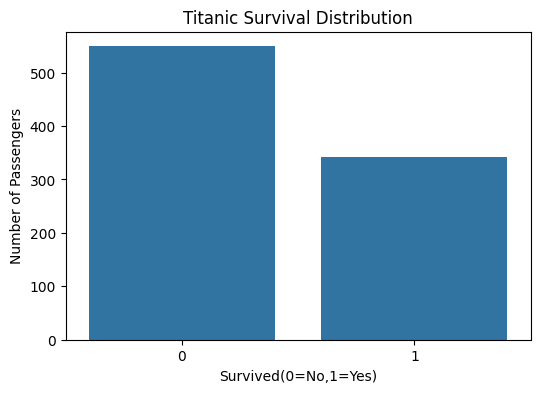

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived",data=df)
plt.title("Titanic Survival Distribution")
plt.xlabel("Survived(0=No,1=Yes)")
plt.ylabel("Number of Passengers")
plt.show()

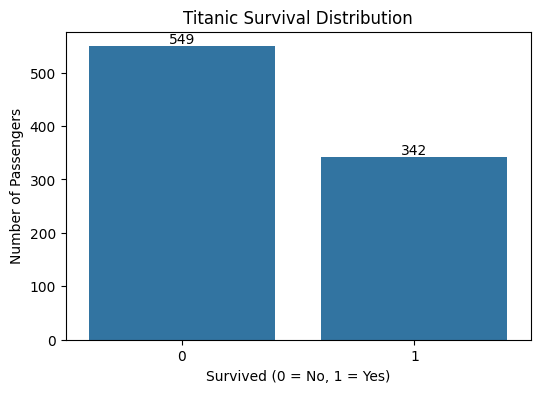

In [23]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x="Survived", data=df)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Did gender affect survival?

In [24]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [25]:
pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


Visualize Survival by Gender
Let's compare survival rates between male and female passengers.

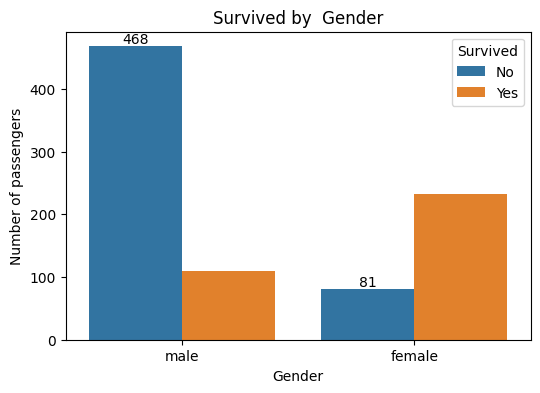

In [31]:
plt.figure(figsize=(6,4))
ax=sns.countplot(x="Sex",hue="Survived",data=df)
plt.title("Survived by  Gender")
plt.xlabel("Gender")
plt.ylabel("Number of passengers")
plt.legend(title="Survived",labels=["No","Yes"])
for container in ax.containers:
  ax.bar_label(container)
  plt.show()

### Observation

The visualization shows a clear difference in survival outcomes between male and female passengers. Female passengers had a higher survival proportion than male passengers in this dataset.

Survival by Passenger Class

In [32]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


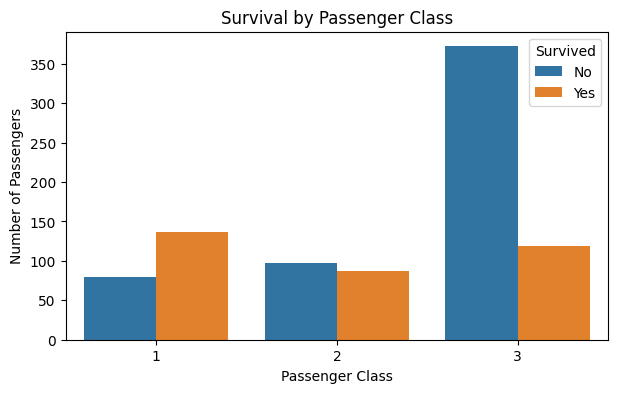

In [33]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

Survival Rate by Passenger Class

In [34]:
survival_rate = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

survival_rate

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


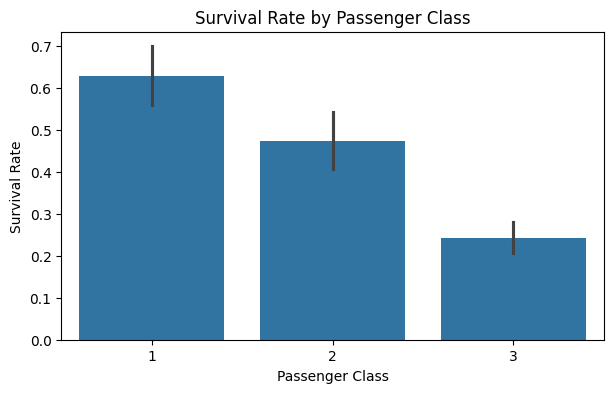

In [35]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x="Pclass",
    y="Survived",
    data=df,
    estimator="mean"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [38]:
survival_rate=pd.crosstab(
    df['Pclass'],
    df["Survived"],
    normalize='index'
    )*100
survival_rate

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [39]:
df['Age'].describe()

,Age
count,891.000000
mean,29.361582
std,13.019697
min,0.420000
25%,22.000000
50%,28.000000
75%,35.000000
max,80.000000


In [40]:
df['Age'].isnull().sum()

np.int64(0)

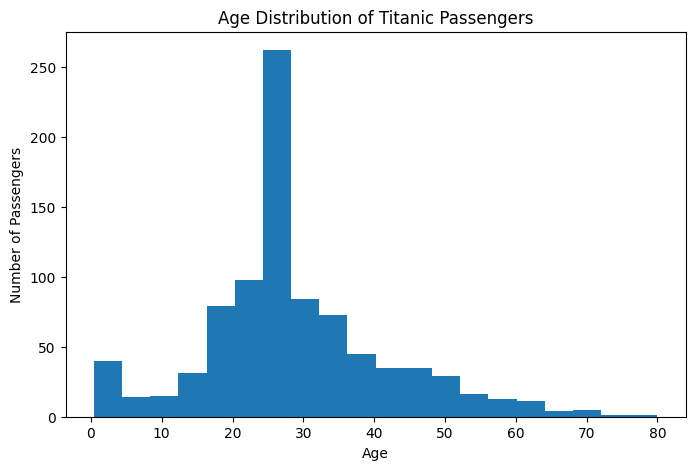

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Age'].dropna(), bins=20)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution of Titanic Passengers')
plt.show()

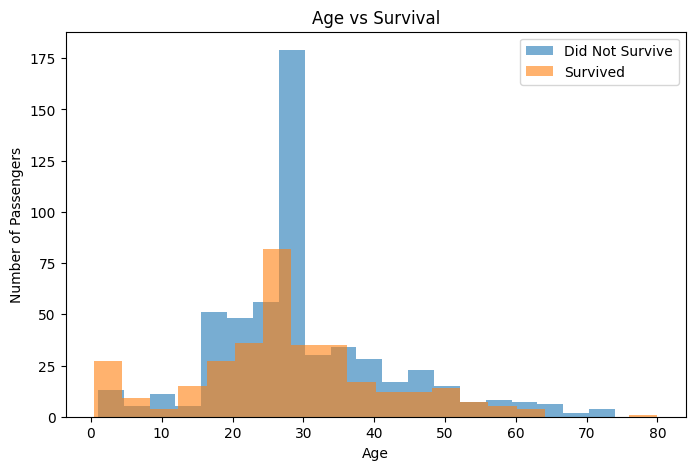

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df[df['Survived'] == 0]['Age'].dropna(), bins=20, alpha=0.6, label='Did Not Survive')
plt.hist(df[df['Survived'] == 1]['Age'].dropna(), bins=20, alpha=0.6, label='Survived')

plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age vs Survival')
plt.legend()
plt.show()

In [43]:
df['Age'].mean()

np.float64(29.36158249158249)

In [44]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df['AgeGroup'].value_counts()

,count
AgeGroup,
Young Adult,535
Adult,195
Teenager,70
Child,69
Senior,22


In [45]:
df.groupby('AgeGroup')['Survived'].mean().sort_values(ascending=False)

/tmp/ipykernel_1195/435378930.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean().sort_values(ascending=False)


,Survived
AgeGroup,
Child,0.579710
Teenager,0.428571
Adult,0.400000
Young Adult,0.353271
Senior,0.227273


Passenger count by gender

In [46]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


Survival rate by gender

In [47]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [48]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

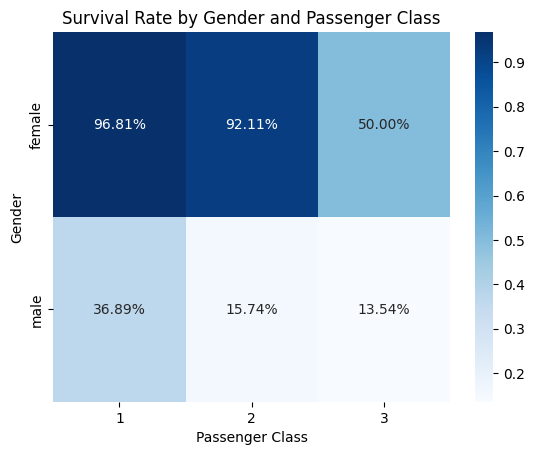

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

survival_table = df.pivot_table(
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
)

sns.heatmap(survival_table, annot=True, fmt='.2%', cmap='Blues')

plt.title('Survival Rate by Gender and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Gender')
plt.show()

Average age: 29.36
years

Largest age group: Young Adult — 535 passengers

Highest age-group survival: Child — 57.97%

Female passengers: 314

Male passengers: 577

Female survival: 74.20%

Male survival: 18.89%

Female 1st-class
survival: 96.81%

Female 2nd-class survival: 92.11%

Female 3rd-class survival: 50.00%



Fare Analysis

In [50]:
df.groupby('Survived')['Fare'].mean()

,Fare
Survived,
0,22.117887
1,48.395408


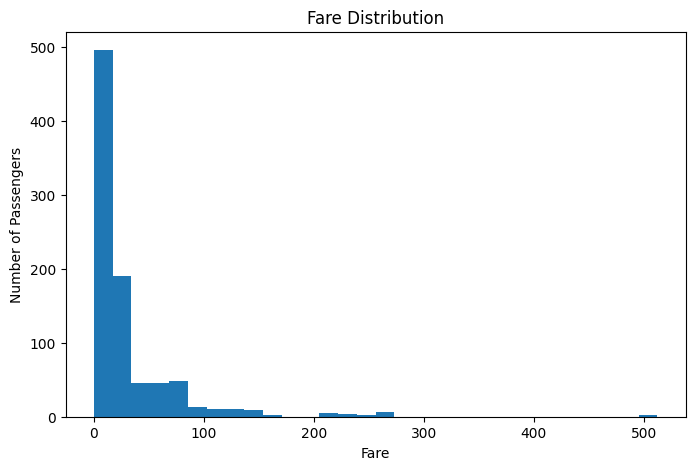

In [51]:
plt.figure(figsize=(8,5))

plt.hist(df['Fare'], bins=30)

plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.title('Fare Distribution')
plt.show()

Family Size Analysis

In [53]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [54]:
df['FamilySize'].value_counts().sort_index()

,count
FamilySize,
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


In [55]:
df.groupby('FamilySize')['Survived'].mean().sort_index()

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


Your current findings are:

Feature	Finding
Average Age	29.36 years

Largest Age Group	Young Adult – 535
Female Survival	74.20%

Male Survival	18.89%

Female 1st Class Survival	96.81%
Male 3rd Class
Survival	13.54%
Average Fare – Survived	48.40

Average Fare – Not Survived	22.12

Family Size 4 Survival	72.41%

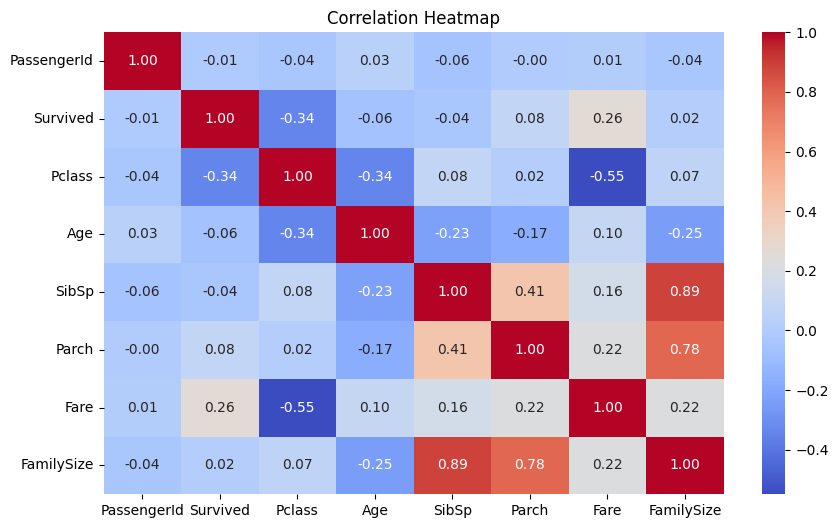

In [56]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

## 7. Key Findings

1. **Passenger Class:** Class 1 passengers had the highest survival rate, while Class 3 had the lowest.

2. **Age:** The average passenger age was approximately **29.36 years**. Young Adults (19–35) were the largest age group with **535 passengers**.

3. **Age and Survival:** Children had the highest observed survival rate among the defined age groups at approximately **57.97%**, while seniors had the lowest at approximately **22.73%**.

4. **Gender:** Female passengers had a substantially higher survival rate (**74.20%**) than male passengers (**18.89%**).

5. **Gender and Class:** Survival varied considerably across gender and passenger class. Female passengers in 1st class had an observed survival rate of **96.81%**, while male passengers in 3rd class had an observed survival rate of **13.54%**.

6. **Fare:** Passengers who survived paid an average fare of approximately **48.40**, compared with **22.12** for passengers who did not survive.

7. **Family Size:** Small family groups showed higher observed survival rates in several groups. Family size 4 had the highest observed rate in this analysis at approximately **72.41%**.

8. **Overall:** The analysis shows that passenger class, gender, age, fare, and family size were all associated with survival outcomes in this Titanic dataset.


## 8. Conclusion

The Titanic dataset provides a useful introduction to exploratory data analysis and demonstrates how Python can be used to discover patterns in real-world data.

The analysis found substantial differences in survival across passenger class and gender, along with observable patterns related to age, fare, and family size.

This project helped demonstrate the complete basic EDA workflow:

* Loading and understanding a dataset
* Checking data types and missing values
* Creating new features
* Grouping and aggregating data
* Calculating survival rates
* Creating visualizations
* Interpreting patterns from the data

These findings can also be used as a starting point for a future **machine learning model to predict passenger survival**.
